# Tarea 5: Clasificación con SVM y optimización de hiperparámetros
## Parte 1 — Exploración del dataset

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['label'] = y

print("Primeras filas del dataset:")
display(df.head())

print("\nDistribución de las clases (0 = Maligno, 1 = Benigno):")
print(df['label'].value_counts())

Primeras filas del dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Distribución de las clases (0 = Maligno, 1 = Benigno):
label
1    357
0    212
Name: count, dtype: int64


## Parte 2 — SVM básico y visualización (Kernel Lineal)

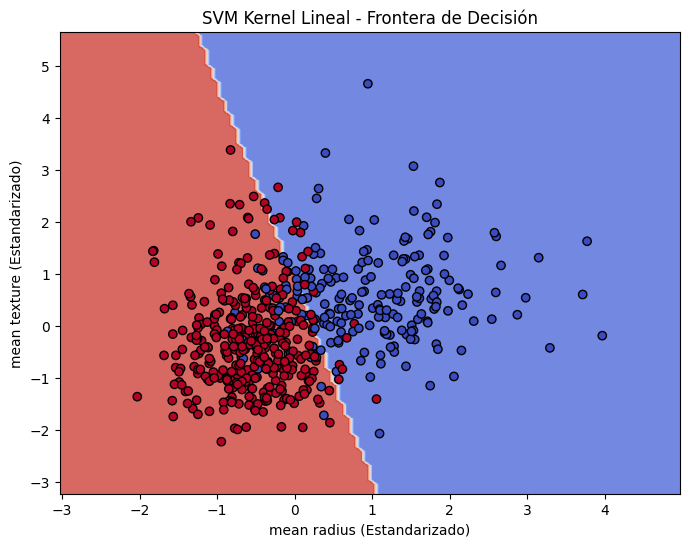

In [2]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

# Seleccionar solo las dos primeras variables para poder visualizar la frontera en 2D
X_2d = X[:, :2] 

# Escalar los datos (importante para SVM)
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)

# Crear y entrenar el modelo SVM con kernel lineal (básico)
svm_lineal = SVC(kernel='linear', C=1.0)
svm_lineal.fit(X_2d_scaled, y)

# Visualizar la frontera
plt.figure(figsize=(8, 6))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_lineal, X_2d_scaled, response_method="predict",
    cmap=plt.cm.coolwarm, alpha=0.8, ax=plt.gca()
)
plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("SVM Kernel Lineal - Frontera de Decisión")
plt.xlabel(data.feature_names[0] + " (Estandarizado)")
plt.ylabel(data.feature_names[1] + " (Estandarizado)")
plt.show()

## Parte 3 — Probar distintos kernels (`linear`, `rbf`, `poly`, `sigmoid`)

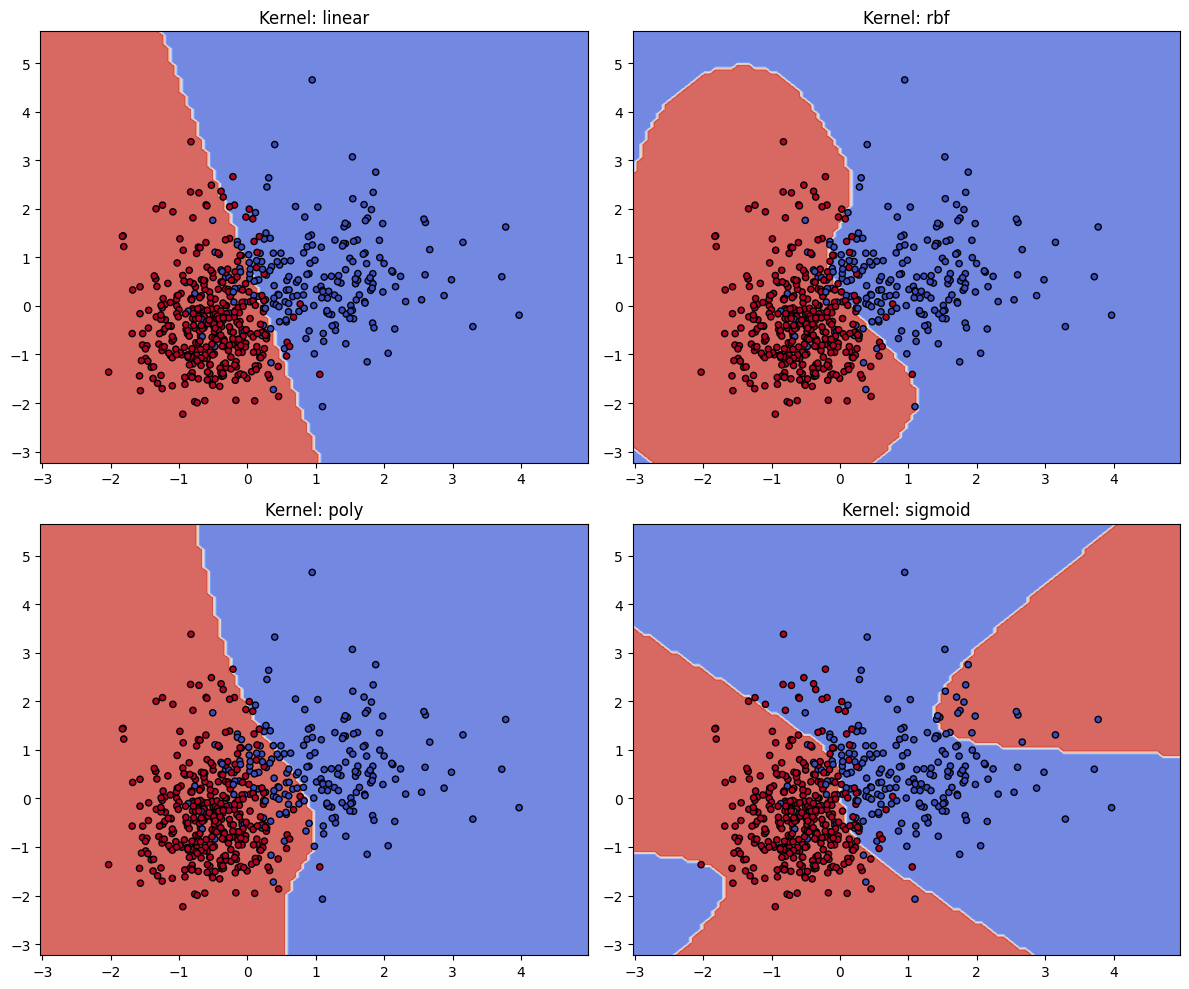

In [3]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, kernel in zip(axes.ravel(), kernels):
    # Entrenar modelo
    clf = SVC(kernel=kernel, C=1.0, gamma='scale')
    clf.fit(X_2d_scaled, y)
    
    # Dibujar frontera
    DecisionBoundaryDisplay.from_estimator(
        clf, X_2d_scaled, response_method="predict",
        cmap=plt.cm.coolwarm, alpha=0.8, ax=ax
    )
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(f"Kernel: {kernel}")

plt.tight_layout()
plt.show()

## Parte 4 — Validación cruzada y GridSearch
Optimización de `C` y `gamma` usando `GridSearchCV` con 5-fold CV y `kernel='rbf'`.

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Aquí usamos TODAS las variables para entrenar un modelo real (no solo 2)
X_scaled = scaler.fit_transform(X) 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Definir la rejilla de parámetros
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Configurar GridSearchCV
grid = GridSearchCV(SVC(), param_grid, cv=5, refit=True, verbose=1)

# Entrenar
grid.fit(X_train, y_train)

print("\n--- Resultados GridSearchCV ---")
print(f"Mejores hiperparámetros encontrados: {grid.best_params_}")
print(f"Mejor score (CV): {grid.best_score_:.4f}")

# Evaluar en el conjunto de test
y_pred = grid.predict(X_test)
test_score = accuracy_score(y_test, y_pred)
print(f"Score final en Test: {test_score:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- Resultados GridSearchCV ---
Mejores hiperparámetros encontrados: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor score (CV): 0.9673
Score final en Test: 0.9883


### Extra Parte 4: Visualización de cambios en C y Gamma
Generando dos combinaciones distintas para ver cómo cambia la frontera (usando solo 2 variables).

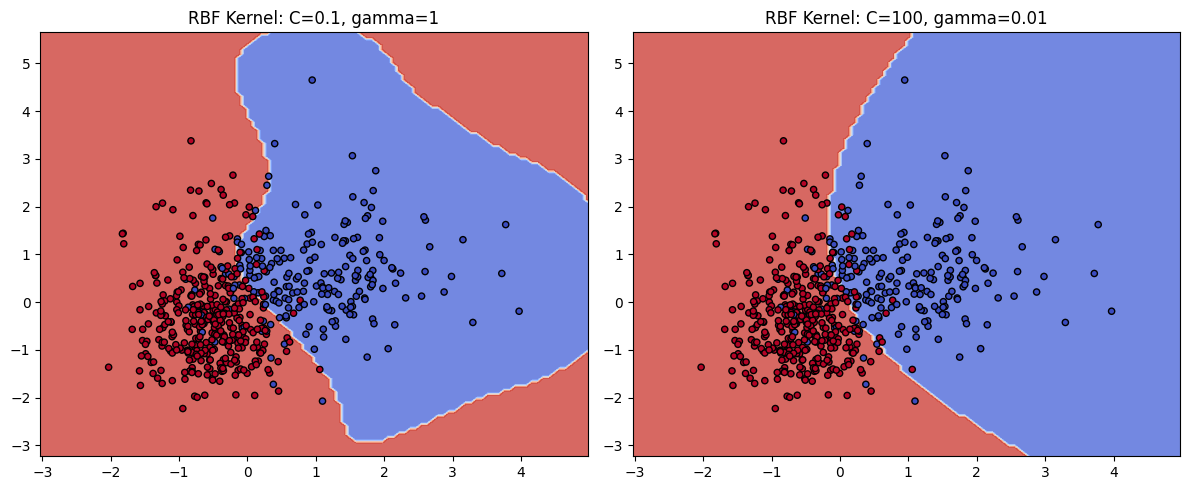

In [5]:
# Combinaciones de prueba para ver el efecto en la frontera
configs = [
    {'C': 0.1, 'gamma': 1},     # Modelo muy regularizado
    {'C': 100, 'gamma': 0.01}   # Modelo menos regularizado
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, config in zip(axes, configs):
    # Entrenar modelo con X_2d_scaled para poder graficar
    clf = SVC(kernel='rbf', C=config['C'], gamma=config['gamma'])
    clf.fit(X_2d_scaled, y)
    
    # Dibujar frontera
    DecisionBoundaryDisplay.from_estimator(
        clf, X_2d_scaled, response_method="predict",
        cmap=plt.cm.coolwarm, alpha=0.8, ax=ax
    )
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    ax.set_title(f"RBF Kernel: C={config['C']}, gamma={config['gamma']}")

plt.tight_layout()
plt.show()